## Módulo III: Preprocesamiento 

### Datos nulos  y su tratamiento II

#### Objetivo

* Entender y utilizar el RMSE como métrica de ajuste en un modelo de regresión.
* Presentar un problema de serie de tiempo en el cual se necesiten sustituir datos (durante y después).
    * Hablar de variables muy básicas para entrenar: Rezagos de la serie (estilo modelos AR).
    * Por no ser el objetivo de la actividad, no se separarán conjuntos train/test/OOS/OOT.
* Crear un método de sustitución de datos vía regresión.
* Mostrar gráficamente el ajuste de los datos.
    * Adjuntar RMSE.

#### Actividad 1 guiada:
* Tomar los datos de `actividad1_6_0.csv`.
* Graficar los datos.
* Crear un método de regresión en el cual se muestren gráficamente además de con una medición de RMSE.
    * Probar el performance comparando con el archivo `actividad1a_6_0.csv`.
 
#### Actividad 2 autónoma:
* Repetir actividad uno con el archivo `actividad2_6_0.csv`.
* Probar el performance del modelo con los datos reales en el archivo `actividad2a_6_0.csv`.
    * En este archivo viene toda la serie de tiempo.
* Responda: 
    * ¿Por qué el modelo de la actividad 1 tuvo un mejor ajuste? 



In [1]:
import os
import datetime
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd
from copy import deepcopy
import numpy as np
%matplotlib inline
plt.style.use('ggplot')

Un modelo de regresión se puede definir de la siguiente forma:
$$\hat{y} = \beta_0x_0 + \beta_1x_1 + \cdots + \beta_nx_n$$
donde $x$ representa a nuestra(s) variable(s) y las betas ($\beta$) representan los coeficientes elegidos. 

Un mayor coeficiente naturalmente representará una mayor influencia por parte de esa variable.


##### ¿Cómo usar un modelo de regresión para llenado de datos? 

Imaginemos que tenemos una serie de tiempo, es decir, datos ordenados a través de la historia (sea ésta minutos, días, meses o cualquier otro). Puede ser que por razones exógenas e incluso desconocidas, se dejaron de registrar datos, por lo que un modelo de este tipo nos puede ayudar para _interpolar_ (datos entre la misma serie) o _extrapolar_ (datos más allá de la serie) información.

Otro ejemplo puede ser en un caso que no sea serie de tiempo, es decir, que tenemos ciertas variables numéricas que simplemente carecen de información (los famosos _nulos_). En ese caso, podemos usar información de otras variables de nuestro dataset para, de nuevo con una regresión, tratar de _rellenar_ la información faltante.


Un modelo usado para _rellenar_ nulos se vería de la siguiente forma: 
$$\hat{y_{t}} = \beta_0y_{t-1} + \beta_1y_{t-2} + \cdots + \beta_ny_{t-n}$$

### Actividad 1: Usando regresiones en acciones de la bolsa

In [2]:
basedir = '.'
df = pd.read_csv(os.path.join(basedir, 'actividad1_6_0.csv'), index_col=0) 
cheat_df = pd.read_csv(os.path.join(basedir, 'actividad1a_6_0.csv'), index_col=0) 



Tenemos una serie de tiempo de `CMG` (Chipotle Mexican Grill). Es la cotización del precio de la acción de la mencionada empresa. 

Analicemos cómo se ve nuestra serie.

Vemos que a nuestra serie de tiempo le faltan pedazos. Como no tenemos otra información más allá del paso del tiempo, lo usaremos a nuestro favor creando **rezagos**, es decir: $t-1, t-2, \dots, t-n$.

Creamos un DataFrame con columnas para los razones

Usaremos el método shift de pandas para causar rezagos.

¿Cómo se ve nuestra serie rezagada?

Ahora nuestro DataFrame tiene "nuevas variables" que usaremos como predictores. Es decir, cada punto en $t$ se volverá una función de los puntos en $t-n, n>0$.


Dado a que el objetivo del modelo es **rellenar información**, podemos usar ambas partes de la gráfica. 

Fitteamos el modelo

Veamos nuestros coeficientes y respondamos: ¿En qué se fija nuestro modelo?

Usemos nuestro modelo para estimar las partes que faltan. 
Tomaremos la serie donde tenía huecos y acomodemos el DataFrame.

Podemos ver que nos falta información, vamos a tener que irla rellenando y _acumulando el error_ (punto negativo a este método).

Vamos a comenzar a estimar el primer punto: 

Antes de ponerlo en nuestro DataFrame e iterar el proceso, recordemos cómo es que se ve: 

Ahora sí lo colocamos otra vez en nuestro DataFrame.

In [1]:
# Colocando las respuestas en un copy 



Hecho eso, tenemos que volver a alimentar nuestro frame, es decir, incorporar el dato estimado en `t` (índice 143) como nuestro `t-1` en el índice 144 (el día siguiente).

Hecho eso, iteremos siguiente el siguiente procedimiento: 

* Estimemos el dato en `t` con la serie desde `t-1` hasta `t-7` llena. 
* Tomemos ese dato estimado y llevémoslo como el `t-1` del día siguiente. 
* Repetir procedimiento pero llenando todos los días previos con estimaciones según vayamos avanzando. 
    

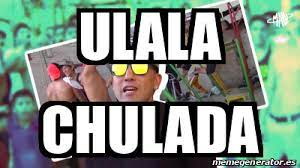

Veamos qué tal se ve la serie: 

¿Cómo definir si un modelo estuvo bien, mal o en el hoyo y cavando? 

Tomemos nuestros datos reales y comparemos con las estimaciones. Para medición del error usaremos el RMSE. 

$$\text{RMSE} = \frac{1}{n} \sum_{i=0}^n (y_i - \hat{y_i})^2$$

Vayamos por partes y primero obtengamos las diferencias. 

Obtengamos el cuadrado. Esta es una buena forma de:
* "Exagerar" las diferencias. Es un "hack" para identificar si las diferencias son chicas o grandes. 
* Eliminar el efecto de "eliminación por signo" (neteo). 

Obtengamos el promedio. 

Regresemos a unidades interpretables (dólares en este caso).

En el futuro podremos utilizar la función de `scikit`: 